## Visualization of training (train and val loss)

In [5]:
import json
import matplotlib.pyplot as plt


def plot_trainer_losses(paths, titles=None, nrows=1, ncols=None, x_axis="step"):
    """
    Plot train/eval losses from Hugging Face trainer_state.json files on subplots.

    paths: list of paths to trainer_state.json files
    titles: list of subplot titles; defaults to filenames
    nrows, ncols: subplot grid shape
    x_axis: "step" or "epoch"
    """
    if isinstance(paths, str):
        paths = [paths]

    n = len(paths)

    if ncols is None:
        ncols = n

    if nrows * ncols < n:
        raise ValueError("nrows * ncols must be at least the number of paths.")

    if titles is None:
        titles = [str(p) for p in paths]

    if len(titles) != n:
        raise ValueError("titles must have the same length as paths.")

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, path, title in zip(axes, paths, titles):
        with open(path, "r") as f:
            state = json.load(f)

        train_x, train_loss = [], []
        eval_x, eval_loss = [], []

        for row in state["log_history"]:
            if x_axis not in row:
                continue

            if "loss" in row:
                train_x.append(row[x_axis])
                train_loss.append(row["loss"])

            if "eval_loss" in row:
                eval_x.append(row[x_axis])
                eval_loss.append(row["eval_loss"])

        ax.plot(train_x, train_loss, label="Train loss")
        ax.plot(eval_x, eval_loss, marker="o", label="Eval loss")

        ax.set_title(title, fontsize=18)
        ax.set_xlabel("Step", fontsize=16)
        ax.set_ylabel("Loss", fontsize=16)
        ax.grid(True, alpha=0.3)
        ax.legend()

    # Hide unused subplot slots
    for ax in axes[n:]:
        ax.axis("off")

    fig.tight_layout()
    return fig, axes[:n]

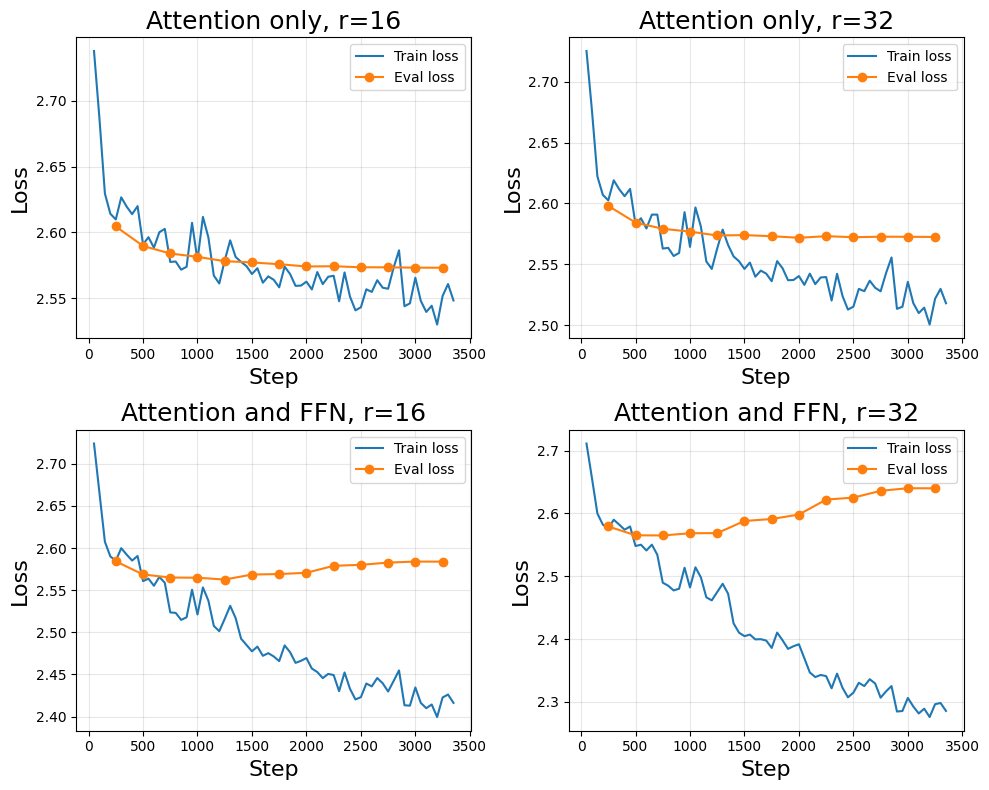

In [ ]:
plot_trainer_losses([
    "../fine_tuning/aria_lora_att_16/checkpoint-3385/trainer_state.json",
    "../fine_tuning/aria_lora_att_32/checkpoint-3385/trainer_state.json",
    "../fine_tuning/aria_lora_all_16/checkpoint-3385/trainer_state.json",
    "../fine_tuning/aria_lora_all_32/checkpoint-3385/trainer_state.json"],
    ["Attention only, r=16",
     "Attention only, r=32",
     "Attention and FFN, r=16",
     "Attention and FFN, r=32"],
    nrows=2, ncols=2)

plt.savefig("fig/loss_curves.pdf")